In [5]:
# Importing libraries 

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [6]:
# Loading the MNIST Data
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

In [7]:
# Split into train, validation, and test sets
X_train_full, X_test, y_train_full, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42
)

In [8]:
# Scale the data (fit only on train, and then apply to valid and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Train and evaluate Logistic Regression 
log_reg = LogisticRegression(solver="lbfgs", max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg_cv_scores = cross_val_score(
    log_reg, X_train_scaled, y_train, cv=3, scoring="accuracy"
)
print("Logistic Regression CV accuracy:", log_reg_cv_scores.mean())

log_valid_pred = log_reg.predict(X_valid_scaled)
print("Logistic Regression Validation Accuracy:", accuracy_score(y_valid, log_valid_pred))

Logistic Regression CV accuracy: 0.9054814814814814
Logistic Regression Validation Accuracy: 0.9213333333333333


In [10]:
# Train and evaluate Random Forest 
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)  # RandomForest doesn't need scaling
rf_cv_scores = cross_val_score(
    rf_clf, X_train, y_train, cv=3, scoring="accuracy"
)
print("Random Forest CV accuracy:", rf_cv_scores.mean())

rf_valid_pred = rf_clf.predict(X_valid)
print("Random Forest Validation Accuracy:", accuracy_score(y_valid, rf_valid_pred))

Random Forest CV accuracy: 0.9645185185185184
Random Forest Validation Accuracy: 0.9721666666666666


In [11]:
# Selecting the best model (choose the one with highest validation accuracy)
best_model = rf_clf if accuracy_score(y_valid, rf_valid_pred) > accuracy_score(y_valid, log_valid_pred) else log_reg
print("Best model selected:", "Random Forest" if best_model == rf_clf else "Logistic Regression")

Best model selected: Random Forest


In [12]:
# Evaluate the best model on the test set
if best_model == log_reg:
    y_test_pred = best_model.predict(X_test_scaled)
else:
    y_test_pred = best_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Final Test Accuracy: 0.9689
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Confusion Matrix:
 [[ 971    0    0    0    0    2    3    1    3    0]
 [   0 1123    2    4    0    2    2    0    1    1]
 [   6    0  996    7    4    0    4    9    6    0]
 [   1    0    9  974    0    5    

In [13]:
print(confusion_matrix(y_test, best_model.predict(X_test)))

[[ 971    0    0    0    0    2    3    1    3    0]
 [   0 1123    2    4    0    2    2    0    1    1]
 [   6    0  996    7    4    0    4    9    6    0]
 [   1    0    9  974    0    5    0    9    9    3]
 [   1    0    2    0  957    0    5    0    3   14]
 [   2    0    0   12    3  859    6    2    5    3]
 [   5    3    0    0    6    4  937    0    3    0]
 [   1    4   20    1    0    0    0  988    4   10]
 [   5    0    7    8    8    4    4    3  926    9]
 [   6    5    2   13   11    4    1    5    4  958]]


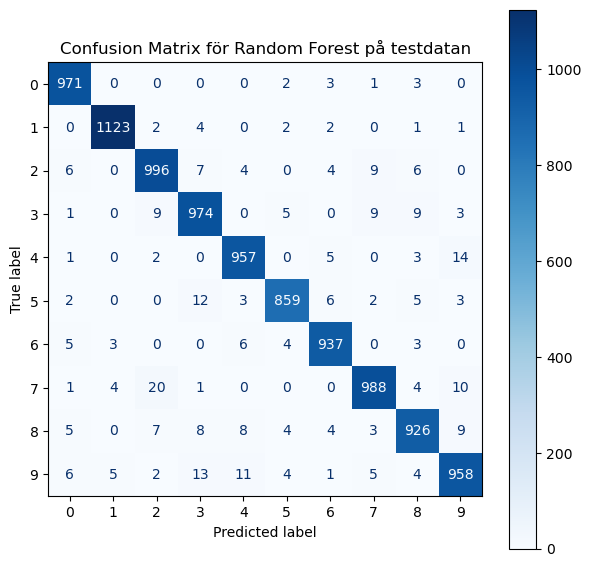

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_model.predict(X_test))
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Confusion Matrix för Random Forest på testdatan")
plt.savefig("random_forest_confusion_matrix.png", dpi=300, bbox_inches='tight')  